

Suppose we wanted to calculate the energy of an electron. What would we do?

Well, we can use the **Time-Independent Schrodinger Equation**, which tells us that the total energy of our wavefunction is the sum of the potential and kinetic energies.
$$
\hat{H} \psi{}(x) = \hat{T}\psi{}(x)  + \hat{V}(x)\psi(x)
$$
Where $\psi{}(x)$ is the wavefunction, E is the total energy, $\hat{H}$ is the Hamiltonian (i.e. the Energy operator), $\hat{T}$ is the kinetic energy operator, and $\hat{V}(x)$ is the potential energy (as a function of x).


For a wavefunction to have a clearly defined energy, it must satisfy: 
$$ \hat{H}\psi = E \psi $$
Where $E$ is constant. In these special cases, we say that $\psi$ is an ___eigenfunction___ of the energy operator $\hat{H}$, and the observed energy $E$ is an ___eigenvalue___. 

To demonstrate how this gives rise to quantization, let's consider a particle confined within a one-dimensional box of length L, where the potential is defined as:
$$ V(x) =
\begin{cases} 
0, & 0 \leq x \leq L \\
\infty, & \text{otherwise}
\end{cases} $$
Within the region where $V(x) = 0$, the Schrodinger equation simplifies to:

$$-\frac{\hbar{}^2}{2m}\frac{d^2}{dx^2}\psi{}(x) = E \psi (x)$$

In the particle-in-a-box model, an electron is confined to a finite region of space, and the allowed quantum states are determined by the Schrödinger equation together with boundary conditions. In lecture, you may have seen that this problem can be solved exactly, giving clean formulas for the allowed wavefunctions and energies. Most real chemical systems, however, do **not** admit closed-form solutions. For real molecules, potentials are complicated, electrons interact, and analytic expressions are rarely obtainable. In practice, chemists often rely on numerical methods to discover physically meaningful solutions rather than writing them down algebraically.

To see how this works in a controlled setting, we will approach the particle-in-a-box problem from a computational perspective. The key physical idea is the relationship between **kinetic energy and curvature**. In quantum mechanics, the kinetic energy operator is proportional to the second derivative of the wavefunction,
$$
\hat{T} \propto -\frac{d^2}{dx^2}.
$$
This means that wavefunctions that bend sharply (large curvature) correspond to higher kinetic energy, while smoother functions correspond to lower kinetic energy. Physically, the ground state of a confined particle must therefore be the smoothest function that satisfies the boundary conditions
$$
\psi(0)=\psi(L)=0.
$$

We can turn this physical idea into a numerical experiment. Instead of solving the differential equation directly, we define a quantity that measures how “energetically costly” a candidate wavefunction is. One useful choice is the Rayleigh quotient,
$$
R[\psi] = \frac{\int_0^L |\psi'(x)|^2 dx}{\int_0^L |\psi(x)|^2 dx}.
$$
The numerator measures how rapidly the function changes — in other words, how much curvature it has — while the denominator normalizes the function so that we compare only shapes, not sizes. Minimizing $R[\psi]$ is therefore equivalent to asking:

> Among all functions that satisfy the boundary conditions, which one has the lowest kinetic energy?

Rather than solving an equation analytically, we will supply a **trial function** and allow a numerical algorithm to reduce its curvature step by step until it reaches a stable shape. The result is the lowest-energy wavefunction supported by the box. In this sense, the computer acts as an experimental instrument: we prepare an initial “sample,” let a procedure act on it, and observe the outcome.

This approach closely mirrors how experimental chemistry works. In a wet lab, we often do not know the final result in advance. Instead, we prepare a system, run a procedure, and observe what state it settles into. Here, our “procedure” is a minimization algorithm, and our “measurement” is the final wavefunction. Just as physical systems naturally evolve toward lower energy states, our numerical system relaxes toward the lowest-curvature, lowest-energy solution allowed by the constraints.

By carrying out this computational experiment, you will see that quantized states do not need to be assumed or memorized — they can emerge naturally from the principle of energy minimization. This is the same philosophy that underlies many modern computational chemistry methods: when exact solutions are unavailable, we construct an energy functional and let numerical methods discover the physically allowed states for us.

---

## Part 1 Scratch (maybe bring this back if time and sanity permits)

**Part C — Compare to the analytic solution**

The exact ground-state wavefunction of the PIB is $\psi_1(x) = \sin(\pi x / L)$.

1. Plot your numerical ground state alongside $\sin(\pi x / L)$ (use a dashed line for one of them so they are distinguishable).
2. Compute the **normalized overlap** between your numerical result and the analytic solution using `np.trapz` for integration:

$$\text{overlap} = \frac{\langle \psi | \phi \rangle}{\sqrt{\langle \psi | \psi \rangle \, \langle \phi | \phi \rangle}}$$

where $\langle f | g \rangle = \int f(x)\,g(x)\,dx \approx$ `np.trapz(f * g, x)`.

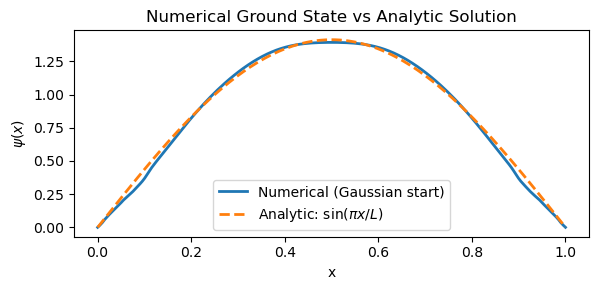

Gaussian bump   overlap = 0.999563
Polynomial      overlap = 0.999818
Sine wave       overlap = 1.000000
